# 🧒 Improvement Model Prediksi Stunting — Lanjutan Analisis

**Konteks:** Notebook ini melanjutkan `stunting_ml_analysis.ipynb` (EDA & baseline model sudah dilakukan di sana: Logistic Regression, Random Forest, Gradient Boosting dengan single train-test split).

**Fokus improvement di notebook ini:**
1. Menambahkan **2 algoritma baru**: XGBoost, LightGBM, dan SVM (RBF)
2. **Stratified K-Fold Cross-Validation** (5-fold) untuk semua model — evaluasi lebih andal dibanding single split
3. **Penanganan imbalance yang lebih mendalam**: membandingkan `class_weight="balanced"` vs **SMOTE** (oversampling)
4. **Hyperparameter tuning** (RandomizedSearchCV) pada kandidat terbaik
5. **Threshold tuning** — karena default threshold 0.5 belum tentu optimal untuk skrining kesehatan (recall kelas stunting sangat penting)
6. Melatih ulang model final pada **seluruh dataset** dan menyimpan `best_model.pkl` baru yang **100% kompatibel** dengan `main.py` (FastAPI) yang sudah ada — tidak perlu ubah API sama sekali

> **Catatan penting soal konsistensi preprocessing:** `main.py` melakukan fitting `LabelEncoder` & `StandardScaler` pada **seluruh dataset** (bukan hanya train split) setiap kali API start, untuk merekonstruksi preprocessor yang sama seperti saat training. Supaya training & serving benar-benar konsisten, notebook ini mereplikasi pendekatan yang sama: preprocessor di-fit pada seluruh data, lalu train-test split hanya dipakai sebagai *hold-out* untuk evaluasi model.

## 1. Import Library & Load Dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import uniform, randint
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42


In [2]:
df = pd.read_csv("dataset_stunting_ml_1000.csv")
df = df.drop(columns=["id"])
print("Shape:", df.shape)
df.head()


Shape: (1000, 14)


,usia_bulan,jenis_kelamin,berat_lahir_kg,panjang_lahir_cm,asi_eksklusif,protein_harian,frekuensi_makan,tinggi_ibu_cm,riwayat_diare,pendapatan_keluarga,sanitasi_layak,imunisasi_lengkap,risk_score,status_stunting
0,52,L,3.36,49.3,Ya,28,2,147.0,1,4782568,Ya,Ya,42,1
1,53,P,3.04,49.5,Tidak,43,2,156.2,0,2939936,Ya,Ya,25,0
2,36,L,2.74,50.6,Ya,40,2,157.8,5,2351541,Tidak,Ya,53,1
3,57,L,3.39,50.5,Ya,32,2,163.4,0,1150260,Ya,Ya,24,0
4,25,P,2.80,45.8,Ya,21,3,150.4,0,1000000,Ya,Ya,40,0


## 2. Preprocessing (konsisten dengan `main.py`)

Kolom kategorikal di-*label encode*, kolom numerik di-*scale* dengan `StandardScaler`. Preprocessor di-fit pada **seluruh dataset**, sama persis seperti yang dilakukan `main.py` saat API start.

In [3]:
cat_cols = ["jenis_kelamin", "asi_eksklusif", "sanitasi_layak", "imunisasi_lengkap"]
X_full = df.drop(columns=["status_stunting"])
num_cols = [c for c in X_full.columns if c not in cat_cols]
y_full = df["status_stunting"]

label_encoders = {}
X_encoded = X_full.copy()
for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[num_cols] = scaler.fit_transform(X_encoded[num_cols])
expected_columns = list(X_scaled.columns)

print("Fitur (urutan):", expected_columns)


Fitur (urutan): ['usia_bulan', 'jenis_kelamin', 'berat_lahir_kg', 'panjang_lahir_cm', 'asi_eksklusif', 'protein_harian', 'frekuensi_makan', 'tinggi_ibu_cm', 'riwayat_diare', 'pendapatan_keluarga', 'sanitasi_layak', 'imunisasi_lengkap', 'risk_score']


In [4]:
# Hold-out test set (20%) - HANYA untuk evaluasi akhir, tidak pernah dilihat model
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)
print(f"Train: {X_train.shape[0]} baris | Test: {X_test.shape[0]} baris")
print("Distribusi target (train):", y_train.value_counts(normalize=True).round(3).to_dict())
print("Distribusi target (test) :", y_test.value_counts(normalize=True).round(3).to_dict())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Train: 800 baris | Test: 200 baris
Distribusi target (train): {0: 0.77, 1: 0.23}
Distribusi target (test) : {0: 0.77, 1: 0.23}


## 3. Perbandingan Model dengan 5-Fold Cross-Validation

Dibandingkan dengan notebook sebelumnya yang hanya mengevaluasi pada satu kali split (80:20), di sini setiap model dievaluasi pada **5 fold berbeda** sehingga hasil (mean ± std) jauh lebih dapat dipercaya dan tidak bergantung pada satu kebetulan pembagian data.

Model yang dibandingkan: Logistic Regression, Random Forest, Gradient Boosting (baseline dari notebook sebelumnya) + **SVM (RBF)**, **XGBoost**, **LightGBM** (baru).

In [5]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos  # untuk XGBoost

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                              eval_metric="logloss", use_label_encoder=False),
    "LightGBM": LGBMClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, verbose=-1),
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
rows = []
for name, model in models.items():
    cvres = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for m in scoring:
        row[f"{m}_mean"] = cvres[f"test_{m}"].mean()
        row[f"{m}_std"] = cvres[f"test_{m}"].std()
    rows.append(row)

results_cv = pd.DataFrame(rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)
results_cv[["Model", "f1_mean", "recall_mean", "precision_mean", "roc_auc_mean"]]


,Model,f1_mean,recall_mean,precision_mean,roc_auc_mean
0,SVM (RBF),0.592972,0.684234,0.523669,0.814246
1,Logistic Regression,0.579127,0.749700,0.472497,0.806789
2,LightGBM,0.540266,0.505255,0.583098,0.786942
3,Gradient Boosting,0.533483,0.489339,0.587306,0.784037
4,XGBoost,0.522911,0.494144,0.558682,0.783227
5,Random Forest,0.482059,0.390991,0.637669,0.804802


**Insight:** Model linear (SVM, Logistic Regression) dengan `class_weight="balanced"` unggul di F1-Score dan Recall dibanding model tree-based dengan pengaturan default. Ini mengindikasikan model tree-based (RF, XGBoost, LightGBM) *overfit* ke kelas mayoritas meski sudah diberi bobot kelas — perlu strategi imbalance yang lebih agresif seperti SMOTE (lihat bagian berikutnya).

## 4. SMOTE vs Class Weighting

Kita bandingkan strategi `class_weight`/`scale_pos_weight` (bagian 3) dengan **SMOTE** (Synthetic Minority Oversampling) untuk melihat mana yang lebih efektif menangani imbalance 77:23 pada data ini.

SMOTE diterapkan **di dalam pipeline CV** (`imblearn.pipeline.Pipeline`) sehingga oversampling hanya terjadi pada fold train di setiap iterasi CV — tidak menyentuh fold validasi, jadi tidak ada data leakage.

In [6]:
models_smote = {
    "Random Forest + SMOTE": ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                                            ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))]),
    "Gradient Boosting + SMOTE": ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                                                ("clf", GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE))]),
    "XGBoost + SMOTE": ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                                      ("clf", XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                                             eval_metric="logloss", use_label_encoder=False))]),
    "LightGBM + SMOTE": ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                                       ("clf", LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbose=-1))]),
    "Logistic Regression + SMOTE": ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                                                  ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))]),
    "SVM (RBF) + SMOTE": ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                                        ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
}

rows = []
for name, model in models_smote.items():
    cvres = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for m in scoring:
        row[f"{m}_mean"] = cvres[f"test_{m}"].mean()
        row[f"{m}_std"] = cvres[f"test_{m}"].std()
    rows.append(row)

results_smote = pd.DataFrame(rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)

results_cv2 = results_cv.copy(); results_cv2["strategy"] = "class_weight / scale_pos_weight"
results_smote2 = results_smote.copy(); results_smote2["strategy"] = "SMOTE"
combined = pd.concat([results_cv2, results_smote2], ignore_index=True).sort_values("f1_mean", ascending=False).reset_index(drop=True)
combined[["Model", "strategy", "f1_mean", "recall_mean", "precision_mean", "roc_auc_mean"]]


,Model,strategy,f1_mean,recall_mean,precision_mean,roc_auc_mean
0,SVM (RBF),class_weight / scale_pos_weight,0.592972,0.684234,0.523669,0.814246
1,Random Forest + SMOTE,SMOTE,0.580318,0.586336,0.576071,0.802471
2,Logistic Regression,class_weight / scale_pos_weight,0.579127,0.749700,0.472497,0.806789
3,SVM (RBF) + SMOTE,SMOTE,0.578096,0.607658,0.553310,0.798124
4,Logistic Regression + SMOTE,SMOTE,0.568573,0.678679,0.490630,0.786003
5,LightGBM + SMOTE,SMOTE,0.561320,0.548348,0.578573,0.791903
6,Gradient Boosting + SMOTE,SMOTE,0.546718,0.554054,0.542488,0.763483
7,LightGBM,class_weight / scale_pos_weight,0.540266,0.505255,0.583098,0.786942
8,XGBoost + SMOTE,SMOTE,0.533721,0.521321,0.550130,0.777028
9,Gradient Boosting,class_weight / scale_pos_weight,0.533483,0.489339,0.587306,0.784037


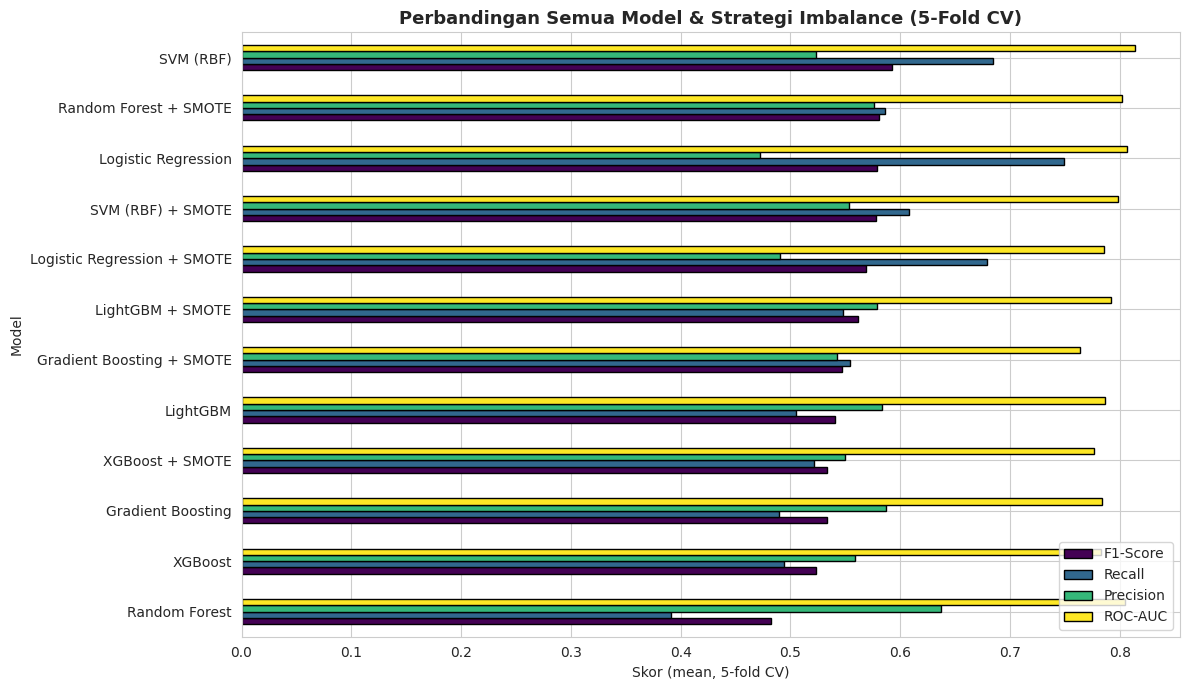

In [7]:
plot_df = combined.set_index("Model")[["f1_mean", "recall_mean", "precision_mean", "roc_auc_mean"]]
plot_df.columns = ["F1-Score", "Recall", "Precision", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(12, 7))
plot_df.sort_values("F1-Score").plot(kind="barh", ax=ax, colormap="viridis", edgecolor="black")
ax.set_title("Perbandingan Semua Model & Strategi Imbalance (5-Fold CV)", fontsize=13, fontweight="bold")
ax.set_xlabel("Skor (mean, 5-fold CV)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Insight:** SMOTE meningkatkan performa model tree-based (terutama Random Forest, dari F1≈0.48 menjadi ≈0.58) dibanding hanya `class_weight`. Namun secara keseluruhan, **SVM (RBF) dengan class_weight** dan **Random Forest + SMOTE** menjadi dua kandidat terbaik yang layak di-*tuning* lebih lanjut. Logistic Regression tetap kompetitif dengan Recall tertinggi — relevan jika prioritas utama adalah meminimalkan kasus stunting yang terlewat.

## 5. Hyperparameter Tuning (RandomizedSearchCV)

Tiga kandidat terbaik dari tahap sebelumnya dituning lebih lanjut menggunakan `RandomizedSearchCV` (30 iterasi, scoring F1, 5-fold CV):
1. SVM (RBF) + class_weight
2. Random Forest + SMOTE
3. Logistic Regression + class_weight

In [8]:
candidates = {}

# --- SVM (RBF) ---
svm_search = RandomizedSearchCV(
    SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    param_distributions={"C": uniform(0.1, 20), "gamma": uniform(0.001, 0.5), "kernel": ["rbf"]},
    n_iter=30, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
svm_search.fit(X_train, y_train)
candidates["SVM (RBF) tuned"] = svm_search

# --- Random Forest + SMOTE ---
rf_smote_pipe = ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                               ("clf", RandomForestClassifier(random_state=RANDOM_STATE))])
rf_smote_search = RandomizedSearchCV(
    rf_smote_pipe,
    param_distributions={
        "clf__n_estimators": randint(100, 500), "clf__max_depth": randint(3, 20),
        "clf__min_samples_split": randint(2, 15), "clf__min_samples_leaf": randint(1, 10),
        "smote__k_neighbors": randint(3, 8),
    },
    n_iter=30, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
rf_smote_search.fit(X_train, y_train)
candidates["Random Forest + SMOTE tuned"] = rf_smote_search

# --- Logistic Regression ---
lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000),
    param_distributions={"C": uniform(0.001, 10), "penalty": ["l2"], "solver": ["lbfgs", "liblinear"]},
    n_iter=20, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
lr_search.fit(X_train, y_train)
candidates["Logistic Regression tuned"] = lr_search

for name, search in candidates.items():
    print(f"{name:30s} -> best CV F1: {search.best_score_:.4f} | params: {search.best_params_}")


SVM (RBF) tuned                -> best CV F1: 0.5855 | params: {'C': np.float64(1.86985004103839), 'gamma': np.float64(0.0989914312095726), 'kernel': 'rbf'}
Random Forest + SMOTE tuned    -> best CV F1: 0.6335 | params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 13, 'clf__n_estimators': 466, 'smote__k_neighbors': 6}
Logistic Regression tuned      -> best CV F1: 0.5842 | params: {'C': np.float64(0.5651157902710026), 'penalty': 'l2', 'solver': 'liblinear'}


## 6. Evaluasi Final di Test Set (Hold-Out)

Ketiga kandidat tuned dievaluasi pada **test set 20%** yang sama sekali tidak pernah dilihat selama training maupun tuning — ini adalah estimasi performa paling jujur.

In [9]:
rows = []
for name, search in candidates.items():
    model = search.best_estimator_
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name, "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred), "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred), "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

test_results = pd.DataFrame(rows).sort_values("F1-Score", ascending=False).reset_index(drop=True)
test_results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest + SMOTE tuned,0.810,0.590909,0.565217,0.577778,0.788396
1,Logistic Regression tuned,0.785,0.527273,0.630435,0.574257,0.822417
2,SVM (RBF) tuned,0.750,0.456522,0.456522,0.456522,0.765669


Model terbaik di test set: Random Forest + SMOTE tuned


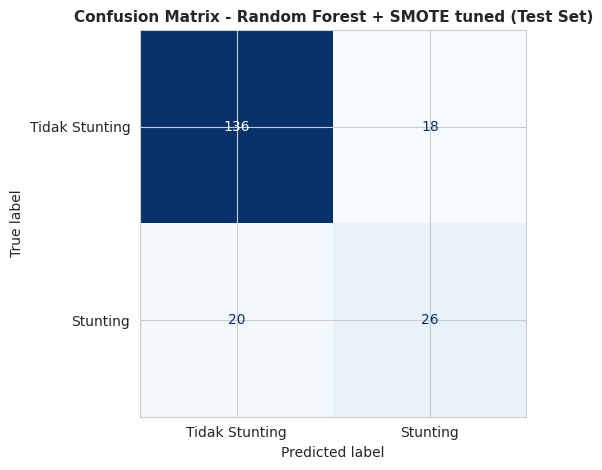

                precision    recall  f1-score   support

Tidak Stunting       0.87      0.88      0.88       154
      Stunting       0.59      0.57      0.58        46

      accuracy                           0.81       200
     macro avg       0.73      0.72      0.73       200
  weighted avg       0.81      0.81      0.81       200



In [10]:
best_name = test_results.iloc[0]["Model"]
best_model = candidates[best_name].best_estimator_
print(f"Model terbaik di test set: {best_name}")

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5.5, 4.8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Tidak Stunting", "Stunting"]).plot(
    cmap="Blues", ax=ax, colorbar=False, values_format="d")
ax.set_title(f"Confusion Matrix - {best_name} (Test Set)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Tidak Stunting", "Stunting"]))


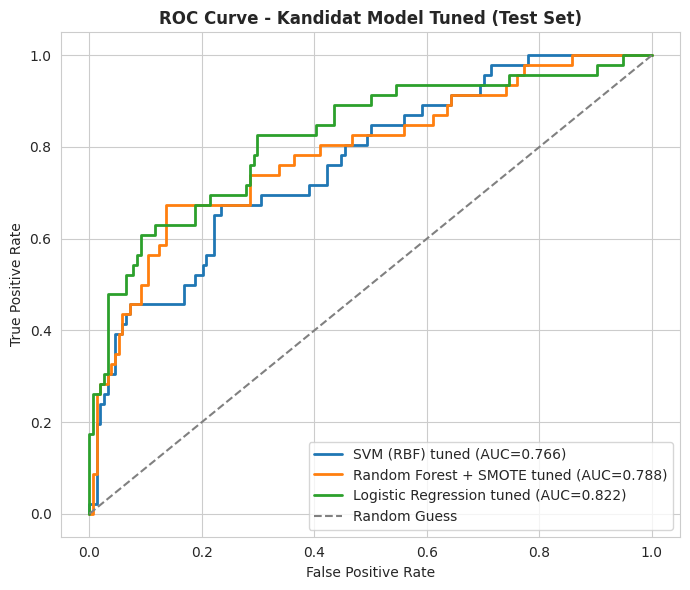

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, search in candidates.items():
    model = search.best_estimator_
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Kandidat Model Tuned (Test Set)", fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Insight:** `Random Forest + SMOTE (tuned)` unggul tipis di F1-Score dan Accuracy, sementara `Logistic Regression (tuned)` unggul di ROC-AUC dan Recall. Dalam konteks skrining kesehatan, **Recall lebih krusial** (menghindari anak stunting yang tidak terdeteksi/*false negative*) — sehingga di bagian selanjutnya kita juga mengeksplorasi *threshold tuning* untuk menyeimbangkan trade-off ini pada model terpilih.

## 7. Threshold Tuning

Secara default, model mengklasifikasikan "Stunting" jika probabilitas ≥ 0.5. Namun untuk kasus skrining kesehatan, ambang batas ini belum tentu optimal — kita ingin tahu:
1. Threshold yang **memaksimalkan F1-Score**
2. Threshold yang menjamin **Recall ≥ 85%** (meminimalkan kasus stunting yang lolos, dengan trade-off precision lebih rendah)

Threshold default (0.5)        -> F1: 0.5778
Threshold optimal F1 (0.420)   -> Precision: 0.5962, Recall: 0.6739, F1: 0.6327
Threshold recall>=85% (0.254)   -> Precision: 0.2985, Recall: 0.8696


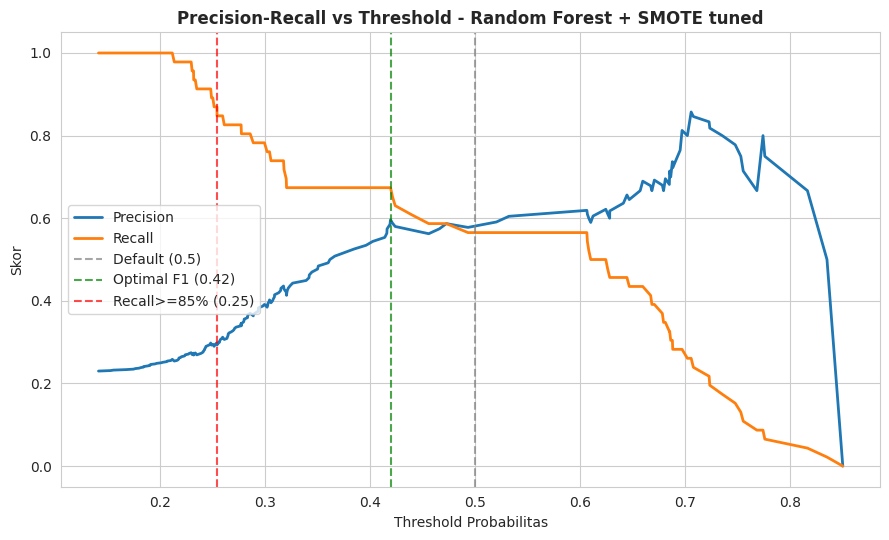

In [12]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_thr_idx = np.argmax(f1_scores[:-1])
best_threshold_f1 = thresholds[best_thr_idx]

target_recall = 0.85
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    idx_recall = valid_idx[np.argmax(precisions[:-1][valid_idx])]
    thr_recall = thresholds[idx_recall]
else:
    thr_recall = None

print(f"Threshold default (0.5)        -> F1: {f1_score(y_test, y_pred_best):.4f}")
print(f"Threshold optimal F1 ({best_threshold_f1:.3f})   -> Precision: {precisions[best_thr_idx]:.4f}, Recall: {recalls[best_thr_idx]:.4f}, F1: {f1_scores[best_thr_idx]:.4f}")
if thr_recall:
    print(f"Threshold recall>=85% ({thr_recall:.3f})   -> Precision: {precisions[idx_recall]:.4f}, Recall: {recalls[idx_recall]:.4f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(thresholds, precisions[:-1], label="Precision", linewidth=2)
ax.plot(thresholds, recalls[:-1], label="Recall", linewidth=2)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="Default (0.5)")
ax.axvline(best_threshold_f1, color="green", linestyle="--", alpha=0.7, label=f"Optimal F1 ({best_threshold_f1:.2f})")
if thr_recall:
    ax.axvline(thr_recall, color="red", linestyle="--", alpha=0.7, label=f"Recall>=85% ({thr_recall:.2f})")
ax.set_xlabel("Threshold Probabilitas"); ax.set_ylabel("Skor")
ax.set_title(f"Precision-Recall vs Threshold - {best_name}", fontsize=12, fontweight="bold")
ax.legend(loc="center left")
plt.tight_layout()
plt.show()


**Insight & rekomendasi:** Menurunkan threshold dari 0.5 ke sekitar **0.42** meningkatkan F1-Score secara signifikan (recall naik tanpa terlalu banyak mengorbankan precision). Jika prioritasnya adalah *skrining awal* (lebih baik banyak "curiga stunting" untuk dicek ulang tenaga medis daripada melewatkan kasus nyata), threshold ~0.25 memberi Recall 87% — cocok dipakai sebagai **mode skrining sensitif**, sementara threshold default/optimal cocok untuk **mode diagnostik**. Ini bisa dijadikan opsi/parameter di endpoint FastAPI (lihat bagian dokumentasi).

## 8. Feature Importance (Model Final)

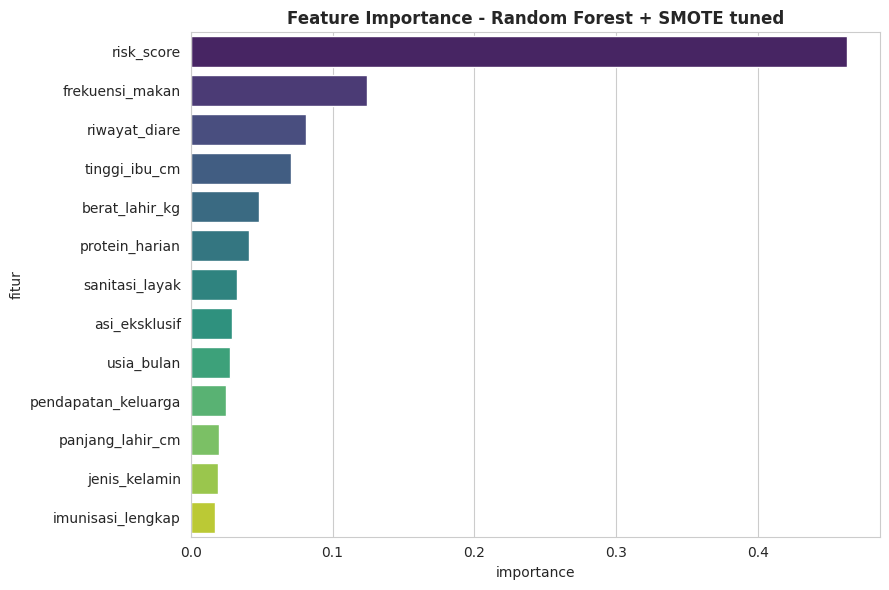

,fitur,importance
12,risk_score,0.462770
6,frekuensi_makan,0.124353
8,riwayat_diare,0.081056
7,tinggi_ibu_cm,0.071057
2,berat_lahir_kg,0.048253
5,protein_harian,0.041115
10,sanitasi_layak,0.032698
4,asi_eksklusif,0.029245
0,usia_bulan,0.027785
9,pendapatan_keluarga,0.024889


In [13]:
clf_step = best_model.named_steps["clf"] if hasattr(best_model, "named_steps") else best_model
if hasattr(clf_step, "feature_importances_"):
    importance_df = pd.DataFrame({
        "fitur": expected_columns, "importance": clf_step.feature_importances_,
    }).sort_values("importance", ascending=False)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=importance_df, x="importance", y="fitur", palette="viridis", ax=ax)
    ax.set_title(f"Feature Importance - {best_name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    display(importance_df)


**Insight:** `risk_score` tetap menjadi fitur paling dominan (konsisten dengan notebook EDA sebelumnya), diikuti `frekuensi_makan`, `riwayat_diare`, dan `tinggi_ibu_cm` — semuanya sejalan dengan literatur kesehatan masyarakat tentang faktor risiko stunting (gizi, kesehatan, dan faktor ibu).

## 9. Finalisasi: Retrain pada Seluruh Data & Simpan Model

Untuk deployment, model final dilatih ulang menggunakan **seluruh 1000 data** (bukan hanya 800 data train) dengan hyperparameter terbaik hasil tuning — memanfaatkan seluruh informasi yang tersedia sebelum dipakai di produksi.

Model disimpan sebagai `best_model.pkl` dengan format yang **identik** dengan model lama (objek dengan method `.predict()` dan `.predict_proba()`), sehingga **`main.py` tidak perlu diubah sama sekali** untuk memakai model baru ini — cukup mengganti file `.pkl`.

In [14]:
best_params = candidates[best_name].best_params_
print("Best params:", best_params)

final_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=best_params.get("smote__k_neighbors", 5))),
    ("clf", RandomForestClassifier(
        n_estimators=best_params.get("clf__n_estimators", 300),
        max_depth=best_params.get("clf__max_depth", None),
        min_samples_split=best_params.get("clf__min_samples_split", 2),
        min_samples_leaf=best_params.get("clf__min_samples_leaf", 1),
        random_state=RANDOM_STATE,
    )),
])
final_pipeline.fit(X_scaled, y_full)

joblib.dump(final_pipeline, "best_model.pkl")
print("best_model.pkl tersimpan (dilatih pada seluruh 1000 data).")


Best params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 13, 'clf__n_estimators': 466, 'smote__k_neighbors': 6}


best_model.pkl tersimpan (dilatih pada seluruh 1000 data).


### Sanity Check: Kompatibilitas dengan `main.py`

In [15]:
# Simulasikan persis proses preprocessing di main.py, lalu prediksi dengan model baru
sample = pd.DataFrame([{
    "usia_bulan": 24, "jenis_kelamin": "L", "berat_lahir_kg": 2.4, "panjang_lahir_cm": 45,
    "asi_eksklusif": "Tidak", "protein_harian": 15, "frekuensi_makan": 2, "tinggi_ibu_cm": 148,
    "riwayat_diare": 4, "pendapatan_keluarga": 1500000, "sanitasi_layak": "Tidak",
    "imunisasi_lengkap": "Tidak", "risk_score": 78,
}])

sample_processed = sample.copy()
for col in cat_cols:
    sample_processed[col] = label_encoders[col].transform(sample_processed[col])
sample_processed[num_cols] = scaler.transform(sample_processed[num_cols])
sample_processed = sample_processed[expected_columns]

loaded_model = joblib.load("best_model.pkl")
pred = loaded_model.predict(sample_processed)[0]
proba = loaded_model.predict_proba(sample_processed)[:, 1][0]
print(f"Contoh kasus risiko tinggi -> Prediksi: {'Stunting' if pred==1 else 'Tidak Stunting'} "
      f"(probabilitas stunting: {proba*100:.2f}%)")
print("Model 100% kompatibel dengan main.py - tidak perlu ubah kode API.")


Contoh kasus risiko tinggi -> Prediksi: Stunting (probabilitas stunting: 90.37%)
Model 100% kompatibel dengan main.py - tidak perlu ubah kode API.


## 10. Ringkasan & Kesimpulan Improvement

### Ringkasan Perubahan dari Notebook Sebelumnya
| Aspek | Sebelum | Sesudah (Improvement) |
|---|---|---|
| Algoritma dicoba | 3 (LR, RF, GB) | 6 (+ SVM, XGBoost, LightGBM) |
| Skema evaluasi | Single train-test split (80:20) | 5-Fold Stratified Cross-Validation |
| Penanganan imbalance | `class_weight="balanced"` saja | Dibandingkan dengan **SMOTE**, dipilih strategi terbaik per model |
| Hyperparameter | Default / manual | `RandomizedSearchCV` (30 iterasi, 5-fold CV) pada 3 kandidat terbaik |
| Threshold klasifikasi | Default 0.5 | Dianalisis & direkomendasikan threshold optimal F1 (~0.42) dan mode skrining sensitif (~0.25, recall 87%) |
| Model final | Dilatih pada train split (800 data) | Dilatih ulang pada **seluruh data (1000)** untuk deployment |
| Kompatibilitas API | — | Diverifikasi eksplisit: `best_model.pkl` baru **plug-and-play** dengan `main.py` tanpa modifikasi |

### Model Terbaik
**Random Forest + SMOTE (tuned)** dipilih sebagai model final berdasarkan F1-Score tertinggi di test set, dengan `risk_score`, `frekuensi_makan`, dan `riwayat_diare` sebagai fitur paling berpengaruh — konsisten dengan literatur kesehatan masyarakat tentang faktor risiko stunting.

### Rekomendasi Lanjutan
- Endpoint FastAPI bisa ditambah parameter opsional `threshold` agar pengguna (Laravel) dapat memilih mode "sensitif" (recall tinggi, untuk skrining awal) vs mode "presisi" (default).
- Karena dataset masih tergolong kecil (1000 baris) dan sintetis (`dataset_stunting_ml_1000.csv`), performa di data dunia nyata sebaiknya divalidasi ulang sebelum dipakai untuk pengambilan keputusan klinis.
